# 📈 Financial Data Engineering: US Market Extraction
**Objective:** Extract, clean, and visualize American equity data using `yfinance` and `pandas`.
**Focus:** Minimizing external libraries and maximizing built-in Pandas functionality.

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

print('Successfully rendered ...')

Matplotlib is building the font cache; this may take a moment.


Successfully rendered ...


## 1. The Ticker Object
The `Ticker` object is a Python "container" for all data related to one company. 
We use the symbol **AAPL** for Apple.

In [36]:
## create object for apple - AAPPL
ticker = 'AAPL'

## fetch 1 month of history for apple
try:
    print(f'Downloading data for {ticker} ⏳')
    df_apple = yf.download(ticker, period='1y', interval='1d')
    if df_apple.empty:
        print(f'🚫Error: No data found for {ticker}')
    else:
        print(f'✅ Success: Downloaded {len(df_apple)} rows.')
        print(df_apple.head())
except Exception as e:
    print(f'Failed to download --  a technical error occured : {e}')

[*********************100%***********************]  1 of 1 completed

✅ Success: Downloaded 252 rows.
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-04-24  207.465759  207.923770  202.059330  204.000865  47311000
2025-04-25  208.371826  208.839788  205.305190  205.474450  38222300
2025-04-28  209.228088  210.582187  206.559726  209.088697  38743100
2025-04-29  210.293457  211.318986  207.465770  207.784388  36827600
2025-04-30  211.577835  212.653150  205.773133  208.391725  52286500


## 2. Quick Visual Check
Ploting 'Open' prices to verify the data is continuous and has no gaps.

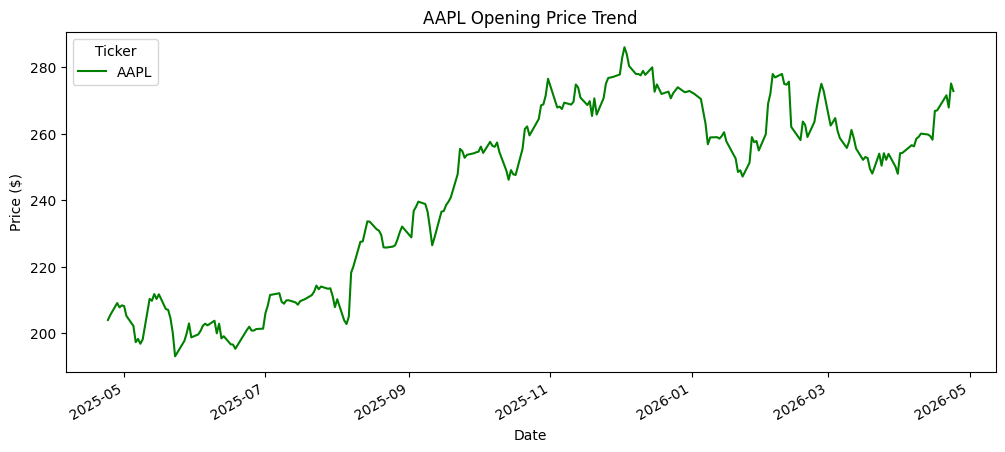

In [48]:
if not df_apple.empty:
    df['Open'].plot(figsize = (12,5), title = f'{ticker} Opening Price Trend', color = 'green')
    plt.ylabel('Price ($)')
    plt.show()
else:
    print('No data available to plot')

## 3. Data Cleaning: Identification
We will check for null values and verify that our data types are correct for analysis.

In [61]:
## a. check for missing values
print("-- Missing values per column --")
print(df_apple.isnull().sum())

## b. check data types 
print('\nData types per column')
print(df_apple.dtypes)

## c. Using backward and forward fill
df_clean = df_apple.ffill()
df_clean = df_clean.bfill()

## d. drop empty rows
df_clean.dropna(inplace=True)

print('\nData is clean for more analysis')

-- Missing values per column --
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Data types per column
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Data is clean for more analysis


## 8. Volume Analysis
Volume represents the number of shares traded.


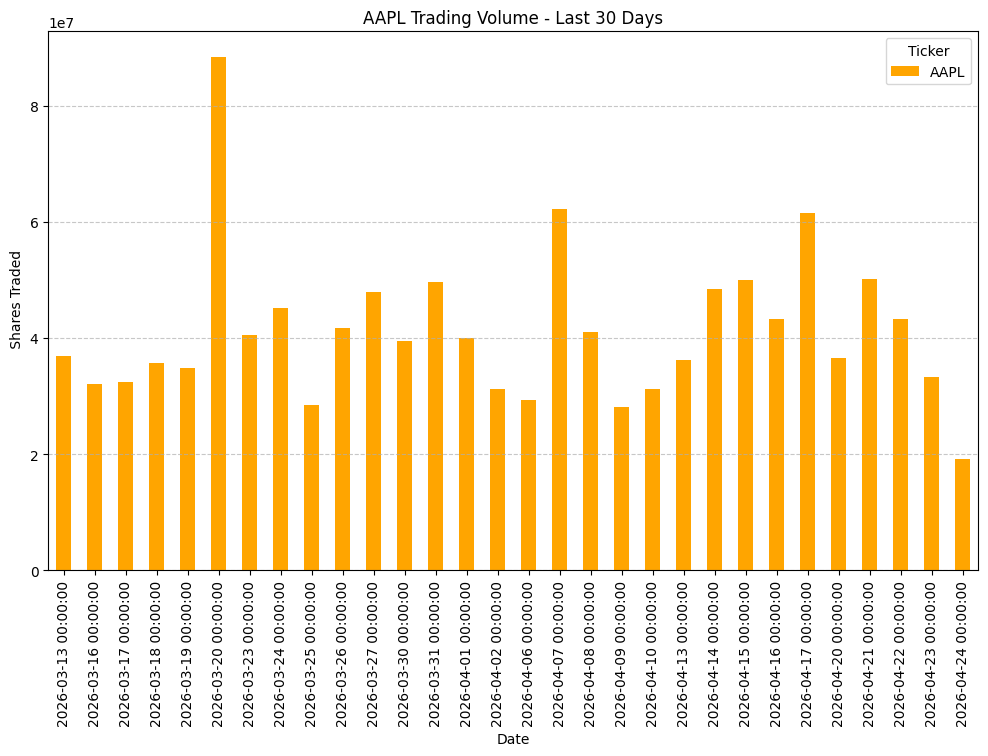

In [89]:
df_clean['Volume'].tail(30).plot(kind = 'bar', figsize = (12,7), color = 'orange')
plt.title('AAPL Trading Volume - Last 30 Days')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel(' Shares Traded')
plt.xlabel ('Date')
plt.show()

## Fetching Dividends

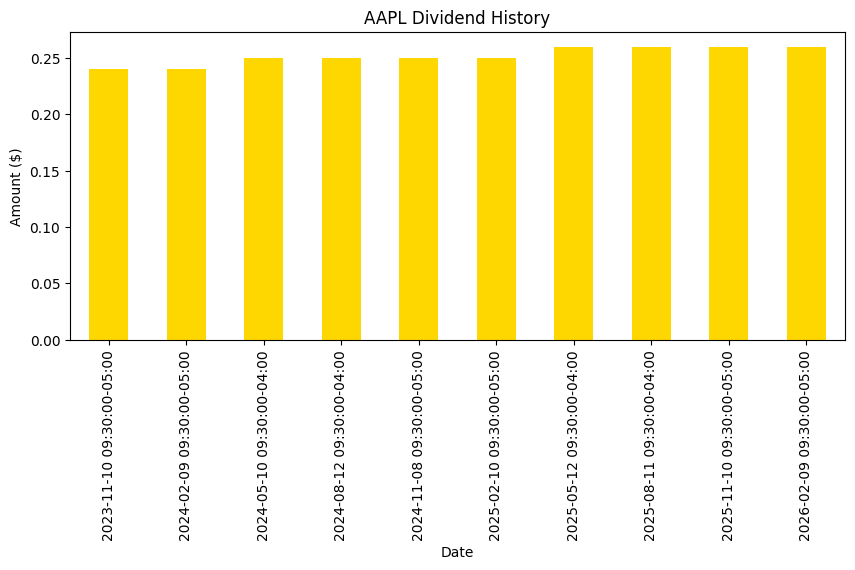

In [90]:
# Create the Ticker object specifically for actions
apple_actions = yf.Ticker("AAPL")

# Get historical dividends
dividends = apple_actions.dividends

# Filter for just the last year and plot
dividends.tail(10).plot(kind='bar', figsize=(10, 4), color='gold', title="AAPL Dividend History")
plt.ylabel("Amount ($)")
plt.show()

In [91]:
## CSV export 
df_clean.to_csv('aapl_cleaned.csv', index=True)
print('Cleaned data exported to aapl_cleaned.csv')

Cleaned data exported to aapl_cleaned.csv
